<a href="https://colab.research.google.com/github/Amruth-a/churn_project/blob/main/whomightleave.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

In [2]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [3]:
df=pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
print(df.dtypes)

print("\nUnique values:")
for col in df.columns:
    print(col, ":", df[col].unique()[:10])

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Unique values:
customerID : ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' '7795-CFOCW' '9237-HQITU'
 '9305-CDSKC' '1452-KIOVK' '6713-OKOMC' '7892-POOKP' '6388-TABGU']
gender : ['Female' 'Male']
SeniorCitizen : [0 1]
Partner : ['Yes' 'No']
Dependents : ['No' 'Yes']
tenure : [ 1 34  2 45  8 22 10 28 62 13]
PhoneService : ['No' 'Yes']
MultipleLines : ['No phone service' 'No' 'Yes']
InternetService : ['D

In [10]:
print("Blank TotalCharges:",
      (df["TotalCharges"].str.strip() == "").sum())

print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False))

Blank TotalCharges: 11

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [11]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [12]:
print(df["TotalCharges"].isnull().sum())
print(df[df["TotalCharges"].isnull()])

11
      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
488   4472-LVYGI  Female              0     Yes        Yes       0   
753   3115-CZMZD    Male              0      No        Yes       0   
936   5709-LVOEQ  Female              0     Yes        Yes       0   
1082  4367-NUYAO    Male              0     Yes        Yes       0   
1340  1371-DWPAZ  Female              0     Yes        Yes       0   
3331  7644-OMVMY    Male              0     Yes        Yes       0   
3826  3213-VVOLG    Male              0     Yes        Yes       0   
4380  2520-SGTTA  Female              0     Yes        Yes       0   
5218  2923-ARZLG    Male              0     Yes        Yes       0   
6670  4075-WKNIU  Female              0     Yes        Yes       0   
6754  2775-SEFEE    Male              0      No        Yes       0   

     PhoneService     MultipleLines InternetService       OnlineSecurity  ...  \
488            No  No phone service             DSL                  Yes  .

In [13]:
print(df[df["TotalCharges"].isnull()][
    ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]
])

      tenure  MonthlyCharges  TotalCharges Churn
488        0           52.55           NaN    No
753        0           20.25           NaN    No
936        0           80.85           NaN    No
1082       0           25.75           NaN    No
1340       0           56.05           NaN    No
3331       0           19.85           NaN    No
3826       0           25.35           NaN    No
4380       0           20.00           NaN    No
5218       0           19.70           NaN    No
6670       0           73.35           NaN    No
6754       0           61.90           NaN    No


In [14]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [15]:
print(df["Churn"].value_counts())

print("\nPercentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


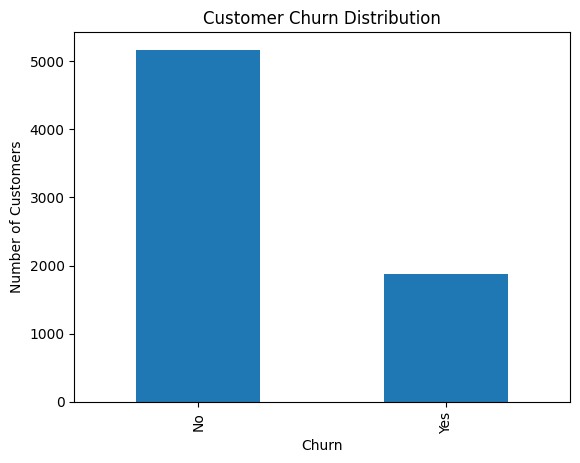

In [16]:
import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(kind="bar")

plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.title("Customer Churn Distribution")
plt.show()

In [17]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    if col not in ["customerID", "Churn"]:
        print("\n", col)
        print(pd.crosstab(
            df[col],
            df["Churn"],
            normalize="index"
        ).round(3))


 gender
Churn      No    Yes
gender              
Female  0.731  0.269
Male    0.738  0.262

 Partner
Churn       No    Yes
Partner              
No       0.670  0.330
Yes      0.803  0.197

 Dependents
Churn          No    Yes
Dependents              
No          0.687  0.313
Yes         0.845  0.155

 PhoneService
Churn            No    Yes
PhoneService              
No            0.751  0.249
Yes           0.733  0.267

 MultipleLines
Churn                No    Yes
MultipleLines                 
No                0.750  0.250
No phone service  0.751  0.249
Yes               0.714  0.286

 InternetService
Churn               No    Yes
InternetService              
DSL              0.810  0.190
Fiber optic      0.581  0.419
No               0.926  0.074

 OnlineSecurity
Churn                   No    Yes
OnlineSecurity                   
No                   0.582  0.418
No internet service  0.926  0.074
Yes                  0.854  0.146

 OnlineBackup
Churn                   No    Ye

In [18]:
print(df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].mean())

print("\nMedian:")
print(df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].median())

          tenure  MonthlyCharges  TotalCharges
Churn                                         
No     37.569965       61.265124   2549.911442
Yes    17.979133       74.441332   1531.796094

Median:
       tenure  MonthlyCharges  TotalCharges
Churn                                      
No       38.0          64.425      1679.525
Yes      10.0          79.650       703.550


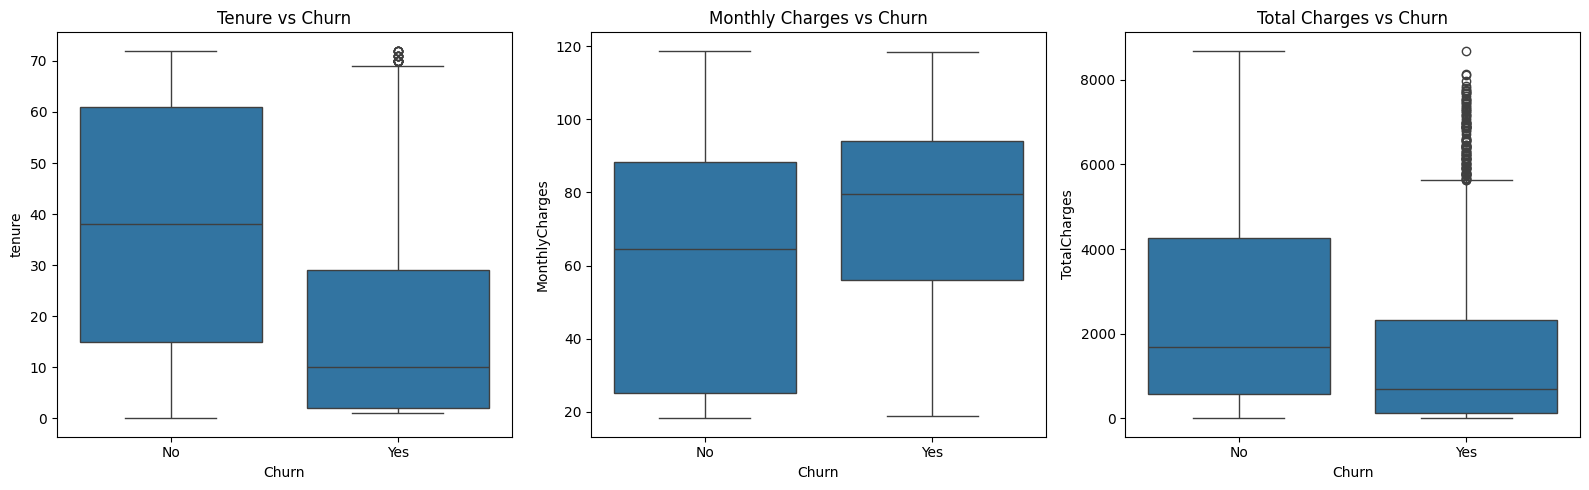

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df, x="Churn", y="tenure", ax=axes[0])
axes[0].set_title("Tenure vs Churn")

sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[1])
axes[1].set_title("Monthly Charges vs Churn")

sns.boxplot(data=df, x="Churn", y="TotalCharges", ax=axes[2])
axes[2].set_title("Total Charges vs Churn")

plt.tight_layout()
plt.show()

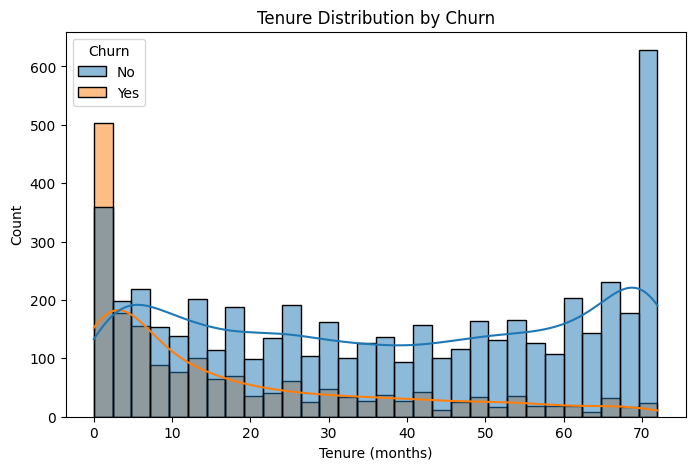

In [20]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (months)")
plt.show()

In [21]:
df = df.drop("customerID", axis=1)

In [22]:
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

In [23]:
df["AverageMonthlySpend"] = df["TotalCharges"] / df["tenure"].replace(0, 1)

In [24]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AverageMonthlySpend
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,29.850000
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,0,55.573529
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,54.075000
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,40.905556
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,75.825000


In [25]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, float("inf")],
    labels=["0-1 year", "1-2 years", "2-4 years", "4+ years"]
)

In [26]:
service_cols = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["TotalServices"] = (df[service_cols] == "Yes").sum(axis=1)

In [27]:
print(df.groupby("Churn")[["TotalServices"]].mean())

print("\nTenure group vs churn:")
print(pd.crosstab(df["TenureGroup"], df["Churn"], normalize="index").round(3))

       TotalServices
Churn               
0           2.135292
1           1.768325

Tenure group vs churn:
Churn            0      1
TenureGroup              
0-1 year     0.526  0.474
1-2 years    0.713  0.287
2-4 years    0.796  0.204
4+ years     0.905  0.095


In [28]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AverageMonthlySpend,TenureGroup,TotalServices
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,29.850000,0-1 year,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,One year,No,Mailed check,56.95,1889.50,0,55.573529,2-4 years,2
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,54.075000,0-1 year,2
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,40.905556,2-4 years,3
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,75.825000,0-1 year,0


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   gender               7043 non-null   object  
 1   SeniorCitizen        7043 non-null   int64   
 2   Partner              7043 non-null   object  
 3   Dependents           7043 non-null   object  
 4   tenure               7043 non-null   int64   
 5   PhoneService         7043 non-null   object  
 6   MultipleLines        7043 non-null   object  
 7   InternetService      7043 non-null   object  
 8   OnlineSecurity       7043 non-null   object  
 9   OnlineBackup         7043 non-null   object  
 10  DeviceProtection     7043 non-null   object  
 11  TechSupport          7043 non-null   object  
 12  StreamingTV          7043 non-null   object  
 13  StreamingMovies      7043 non-null   object  
 14  Contract             7043 non-null   object  
 15  PaperlessBilling     

In [30]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [32]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns

print("Numerical:", list(num_cols))
print("\nCategorical:", list(cat_cols))

Numerical: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'AverageMonthlySpend', 'TotalServices']

Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']


In [33]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

In [34]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [35]:
print("Before encoding:", X_train.shape)
print("After encoding:", X_train_processed.shape)

Before encoding: (5634, 22)
After encoding: (5634, 51)


In [36]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=3000)

lr_model.fit(X_train_processed, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=3000)

In [37]:
from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

In [38]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [39]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_processed, y_train)

y_pred_lr = lr_model.predict(X_test_processed)

In [40]:
from sklearn.metrics import accuracy_score, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.7991483321504613
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [41]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)
print(cm)

[[932 103]
 [180 194]]


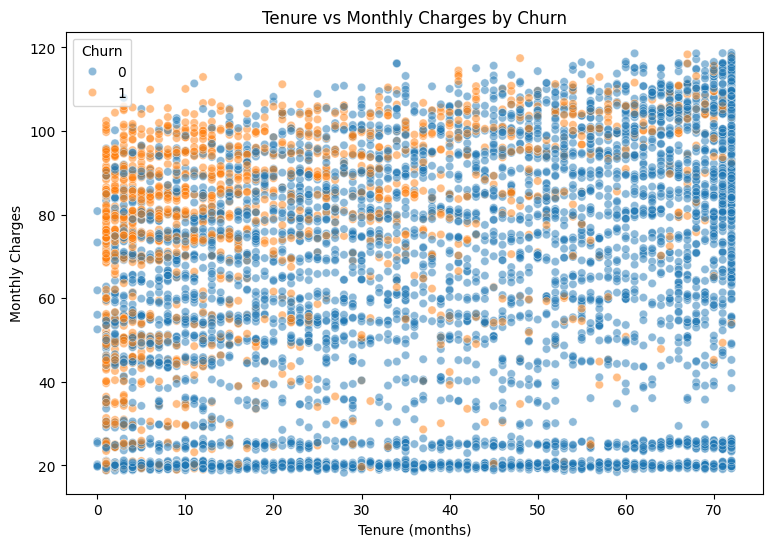

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="tenure",
    y="MonthlyCharges",
    hue="Churn",
    alpha=0.5
)

plt.title("Tenure vs Monthly Charges by Churn")
plt.xlabel("Tenure (months)")
plt.ylabel("Monthly Charges")
plt.show()

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [44]:
y_pred_rf = rf_model.predict(X_test_processed)

In [45]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.7828246983676366
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.61      0.49      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409

[[920 115]
 [191 183]]


In [46]:
lr_balanced = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

lr_balanced.fit(X_train_processed, y_train)

y_pred_balanced = lr_balanced.predict(X_test_processed)

In [47]:
print("Accuracy:", accuracy_score(y_test, y_pred_balanced))
print(classification_report(y_test, y_pred_balanced))
print(confusion_matrix(y_test, y_pred_balanced))

Accuracy: 0.7331440738112136
              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1035
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.73      0.75      1409

[[737 298]
 [ 78 296]]


In [48]:
df["ChargeGroup"] = pd.qcut(
    df["MonthlyCharges"],
    q=3,
    labels=["Low", "Medium", "High"]
)

print(
    pd.crosstab(
        [df["TenureGroup"], df["ChargeGroup"]],
        df["Churn"],
        normalize="index"
    ).round(3)
)

Churn                        0      1
TenureGroup ChargeGroup              
0-1 year    Low          0.690  0.310
            Medium       0.459  0.541
            High         0.263  0.737
1-2 years   Low          0.895  0.105
            Medium       0.715  0.285
            High         0.486  0.514
2-4 years   Low          0.945  0.055
            Medium       0.821  0.179
            High         0.647  0.353
4+ years    Low          0.974  0.026
            Medium       0.945  0.055
            High         0.848  0.152


In [49]:
df = df.drop("AverageMonthlySpend", axis=1)

In [50]:
from sklearn.svm import SVC

svm_model = SVC(kernel="rbf", probability=True, random_state=42)

svm_model.fit(X_train_processed, y_train)

SVC(probability=True, random_state=42)

In [51]:
y_pred_svm = svm_model.predict(X_test_processed)

print("Accuracy:", svm_model.score(X_test_processed, y_test))

from sklearn.metrics import classification_report, confusion_matrix

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

Accuracy: 0.7885024840312278

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1035
           1       0.64      0.46      0.53       374

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.77      0.79      0.78      1409


Confusion Matrix:
[[940  95]
 [203 171]]


In [52]:
print(classification_report(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1035
           1       0.64      0.46      0.53       374

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.77      0.79      0.78      1409

[[940  95]
 [203 171]]


In [53]:
df["Tenure_MonthlyCharges"] = df["tenure"] * df["MonthlyCharges"]

In [54]:
df["NoSecurityOrSupport"] = (
    (df["OnlineSecurity"] == "No") |
    (df["TechSupport"] == "No")
).astype(int)

In [55]:
print(df.groupby("Churn")[[
    "Tenure_MonthlyCharges",
    "NoSecurityOrSupport"
]].mean())

       Tenure_MonthlyCharges  NoSecurityOrSupport
Churn                                            
0                2549.770883              0.53363
1                1531.608828              0.88657


In [56]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [57]:
num_cols = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "TotalServices",
    "Tenure_MonthlyCharges",
    "NoSecurityOrSupport"
]

In [58]:
cat_cols = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
    "TenureGroup"
]

In [59]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)

(5634, 52)
(1409, 52)


In [60]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train_processed, y_train)

GradientBoostingClassifier(random_state=42)

In [61]:
y_pred_gb = gb_model.predict(X_test_processed)

print("Accuracy:", gb_model.score(X_test_processed, y_test))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

Accuracy: 0.801277501774308

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409


Confusion Matrix:
[[935 100]
 [180 194]]


In [62]:
from sklearn.model_selection import cross_val_score

lr_cv = cross_val_score(
    lr_model,
    X_train_processed,
    y_train,
    cv=5,
    scoring="f1"
)

gb_cv = cross_val_score(
    gb_model,
    X_train_processed,
    y_train,
    cv=5,
    scoring="f1"
)

print("Logistic Regression F1:", lr_cv)
print("Mean:", lr_cv.mean())

print("\nGradient Boosting F1:", gb_cv)
print("Mean:", gb_cv.mean())

Logistic Regression F1: [0.63970588 0.58285714 0.58666667 0.57559199 0.59782609]
Mean: 0.5965295528522647

Gradient Boosting F1: [0.62702703 0.57640232 0.60984848 0.54873646 0.55248619]
Mean: 0.5829000965795702


In [63]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_processed, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [64]:
y_pred_xgb = xgb_model.predict(X_test_processed)

print("Accuracy:", xgb_model.score(X_test_processed, y_test))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

Accuracy: 0.8062455642299503

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.68      0.52      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409


Confusion Matrix:
[[942  93]
 [180 194]]


In [65]:
xgb_cv = cross_val_score(
    xgb_model,
    X_train_processed,
    y_train,
    cv=5,
    scoring="f1"
)

print("XGBoost F1:", xgb_cv)
print("Mean:", xgb_cv.mean())

print("\nLogistic Regression Mean F1:", lr_cv.mean())

XGBoost F1: [0.64116576 0.58846154 0.59925094 0.5615942  0.55493482]
Mean: 0.5890814513401559

Logistic Regression Mean F1: 0.5965295528522647


In [66]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_cv = cross_val_score(
    knn_model,
    X_train_processed,
    y_train,
    cv=5,
    scoring="f1"
)

print("KNN F1:", knn_cv)
print("Mean:", knn_cv.mean())
print("Logistic Regression Mean F1:", lr_cv.mean())

KNN F1: [0.55958549 0.52517986 0.5404475  0.5626072  0.52810903]
Mean: 0.5431858171446938
Logistic Regression Mean F1: 0.5965295528522647


In [67]:
# Retrain the model on the newly processed training data (52 features)
lr_model.fit(X_train_processed, y_train)

# Now predict probabilities on the matching test data
y_prob = lr_model.predict_proba(X_test_processed)[:, 1]

print(y_prob[:20])

[0.04784873 0.71747919 0.04837478 0.31953685 0.0217797  0.54679819
 0.36193092 0.10886482 0.00460292 0.32158723 0.26009658 0.06445805
 0.20346389 0.7230896  0.08962589 0.0608437  0.03043813 0.58615874
 0.19780543 0.07467516]


In [68]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [69]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_processed, y_train)

y_pred_lr = lr_model.predict(X_test_processed)

In [70]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(5634, 52)
(1409, 52)


In [71]:
y_prob = lr_model.predict_proba(X_test_processed)[:, 1]

print(y_prob[:20])

[0.04784873 0.71747919 0.04837478 0.31953685 0.0217797  0.54679819
 0.36193092 0.10886482 0.00460292 0.32158723 0.26009658 0.06445805
 0.20346389 0.7230896  0.08962589 0.0608437  0.03043813 0.58615874
 0.19780543 0.07467516]


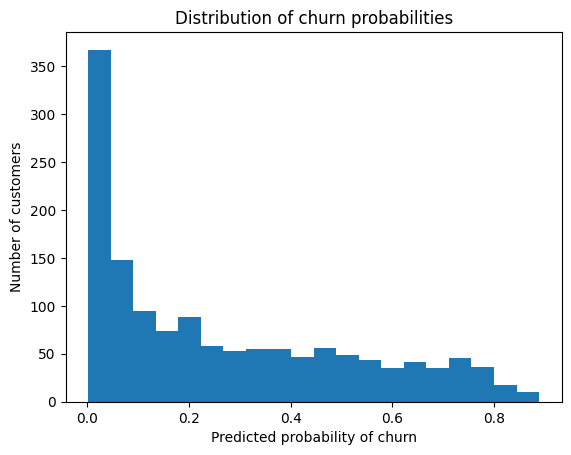

In [72]:
import matplotlib.pyplot as plt

plt.hist(y_prob, bins=20)
plt.xlabel("Predicted probability of churn")
plt.ylabel("Number of customers")
plt.title("Distribution of churn probabilities")
plt.show()

In [73]:
results = pd.DataFrame({
    "probability": y_prob,
    "actual": y_test.values
})

results["range"] = pd.cut(
    results["probability"],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    include_lowest=True
)

print(
    results.groupby("range", observed=False)["actual"]
    .agg(["count", "mean"])
)

               count      mean
range                         
(-0.001, 0.2]    735  0.072109
(0.2, 0.4]       256  0.300781
(0.4, 0.6]       213  0.464789
(0.6, 0.8]       178  0.702247
(0.8, 1.0]        27  0.740741


In [74]:
uncertain = (y_prob >= 0.4) & (y_prob <= 0.6)

print("Total customers:", len(y_prob))
print("Abstained:", uncertain.sum())
print("Predicted:", (~uncertain).sum())
print("Coverage:", (~uncertain).mean())

Total customers: 1409
Abstained: 213
Predicted: 1196
Coverage: 0.8488289567068843


In [75]:
confident_idx = ~uncertain

y_true_confident = y_test.values[confident_idx]
y_pred_confident = (y_prob[confident_idx] >= 0.5).astype(int)

from sklearn.metrics import accuracy_score, f1_score

print("Accuracy on confident predictions:",
      accuracy_score(y_true_confident, y_pred_confident))

print("F1 on confident predictions:",
      f1_score(y_true_confident, y_pred_confident))

Accuracy on confident predictions: 0.8411371237458194
F1 on confident predictions: 0.6041666666666666


In [80]:
test_features = feature_engineering(X_train.copy())

print(test_features.shape)
print(test_features.columns)

(5634, 24)
Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'TenureGroup', 'TotalServices',
       'ChargeGroup', 'Tenure_MonthlyCharges', 'NoSecurityOrSupport'],
      dtype='object')


In [81]:
def feature_engineering(df):
    df = df.copy()

    df["TenureGroup"] = pd.cut(
        df["tenure"],
        bins=[-1, 12, 24, 48, float("inf")],
        labels=["0-1 year", "1-2 years", "2-4 years", "4+ years"]
    )

    service_cols = [
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies"
    ]

    df["TotalServices"] = (df[service_cols] == "Yes").sum(axis=1)

    df["Tenure_MonthlyCharges"] = (
        df["tenure"] * df["MonthlyCharges"]
    )

    df["NoSecurityOrSupport"] = (
        (df["OnlineSecurity"] == "No") |
        (df["TechSupport"] == "No")
    ).astype(int)

    return df

In [82]:
test_features = feature_engineering(X_train.copy())

print(test_features.shape)
print(test_features.columns)

(5634, 24)
Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'TenureGroup', 'TotalServices',
       'ChargeGroup', 'Tenure_MonthlyCharges', 'NoSecurityOrSupport'],
      dtype='object')


In [83]:
df = df.drop("ChargeGroup", axis=1)

In [84]:
test_features = feature_engineering(X_train.copy())

print(test_features.shape)
print(test_features.columns)

(5634, 24)
Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'TenureGroup', 'TotalServices',
       'ChargeGroup', 'Tenure_MonthlyCharges', 'NoSecurityOrSupport'],
      dtype='object')


In [85]:
print("ChargeGroup" in X_train.columns)

True


In [86]:
X_train = X_train.drop("ChargeGroup", axis=1)

In [87]:
test_features = feature_engineering(X_train.copy())

print(test_features.shape)
print(test_features.columns)

(5634, 23)
Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'TenureGroup', 'TotalServices',
       'Tenure_MonthlyCharges', 'NoSecurityOrSupport'],
      dtype='object')


In [88]:
X_train_fe = feature_engineering(X_train.copy())
X_test_fe = feature_engineering(X_test.copy())

In [89]:
X_train_processed = preprocessor.fit_transform(X_train_fe)
X_test_processed = preprocessor.transform(X_test_fe)

In [90]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_processed, y_train)

LogisticRegression(max_iter=1000)

In [91]:
y_pred = lr_model.predict(X_test_processed)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [92]:
from sklearn.pipeline import Pipeline

model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", lr_model)
])

In [93]:
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [94]:
print(X_train_sub.shape)
print(X_val.shape)

(4507, 23)
(1127, 23)


In [95]:
X_train_sub_fe = feature_engineering(X_train_sub.copy())
X_val_fe = feature_engineering(X_val.copy())

In [96]:
preprocessor_val = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

X_train_sub_processed = preprocessor_val.fit_transform(X_train_sub_fe)
X_val_processed = preprocessor_val.transform(X_val_fe)

In [97]:
lr_val = LogisticRegression(max_iter=1000)

lr_val.fit(X_train_sub_processed, y_train_sub)

LogisticRegression(max_iter=1000)

In [98]:
val_prob = lr_val.predict_proba(X_val_processed)[:, 1]

In [99]:
print(val_prob.shape)
print(val_prob[:10])

(1127,)
[0.14213451 0.0176829  0.03926414 0.17459673 0.24587181 0.05682536
 0.24506897 0.01631505 0.01449439 0.26605612]


In [100]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

bands = [
    (0.45, 0.55),
    (0.40, 0.60),
    (0.35, 0.65),
    (0.30, 0.70)
]

for low, high in bands:

    confident = (val_prob < low) | (val_prob > high)

    y_pred_confident = (val_prob[confident] >= 0.5).astype(int)

    accuracy = accuracy_score(y_val[confident], y_pred_confident)
    f1 = f1_score(y_val[confident], y_pred_confident)

    coverage = confident.mean()
    abstention = 1 - coverage

    print(
        f"Band {low}-{high} | "
        f"Coverage: {coverage:.2%} | "
        f"Uncertain: {abstention:.2%} | "
        f"Accuracy: {accuracy:.4f} | "
        f"F1: {f1:.4f}"
    )

Band 0.45-0.55 | Coverage: 93.43% | Uncertain: 6.57% | Accuracy: 0.8367 | F1: 0.6211
Band 0.4-0.6 | Coverage: 85.54% | Uncertain: 14.46% | Accuracy: 0.8548 | F1: 0.6237
Band 0.35-0.65 | Coverage: 78.26% | Uncertain: 21.74% | Accuracy: 0.8662 | F1: 0.6040
Band 0.3-0.7 | Coverage: 70.90% | Uncertain: 29.10% | Accuracy: 0.8874 | F1: 0.5833


In [101]:
X_train_fe = feature_engineering(X_train.copy())
X_test_fe = feature_engineering(X_test.copy())

preprocessor_final = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

X_train_processed = preprocessor_final.fit_transform(X_train_fe)
X_test_processed = preprocessor_final.transform(X_test_fe)

lr_final = LogisticRegression(max_iter=1000)
lr_final.fit(X_train_processed, y_train)


LogisticRegression(max_iter=1000)

In [102]:
test_prob = lr_final.predict_proba(X_test_processed)[:, 1]

print(test_prob.shape)

(1409,)


In [103]:
low = 0.40
high = 0.60

confident = (test_prob < low) | (test_prob > high)

y_pred_confident = (test_prob[confident] >= 0.5).astype(int)

accuracy = accuracy_score(
    y_test[confident],
    y_pred_confident
)

f1 = f1_score(
    y_test[confident],
    y_pred_confident
)

coverage = confident.mean()
uncertain_rate = 1 - coverage

print(f"Coverage: {coverage:.2%}")
print(f"Uncertain: {uncertain_rate:.2%}")
print(f"Accuracy on confident predictions: {accuracy:.4f}")
print(f"F1 on confident predictions: {f1:.4f}")


Coverage: 84.88%
Uncertain: 15.12%
Accuracy on confident predictions: 0.8411
F1 on confident predictions: 0.6042
